# Baseline FedAvg supervisionado — ladder de rotulos (cross-device few-shot)

Notebook **somente de leitura/visualizacao**. Nao treina nada e nao escreve em `results/`.

Este e o **contrafactual do Fed-SSL no regime de escassez de rotulo**. O notebook
irmao (`cross_device_avaliation.ipynb`) mede o mesmo baseline com o shard de
orcamento inteiro; aqui ele e medido em 5 degraus de rotulo, que sao os mesmos em
que o braco Fed-SSL sera varrido. A regra da comparacao futura: **Fed-SSL@1-shot
contra FedAvg@1-shot**, nunca contra FedAvg@full.

## Fonte dos dados

Dois caminhos, por um motivo concreto:

| degrau | vem de | por que |
|---|---|---|
| `1, 2, 5, 10` | `results/fedssl_cross_device_parts/*.csv` (`method == 'none'`) | grade nova, **em execucao** — le-se o parcial por job, nunca o CSV consolidado, que o driver so reescreve no fim |
| `full` | `results/fed_cross_device_parts/*.csv` (`local_epochs == 5`) | ja existe, medido na grade **fechada** do commit `20449ab`. Nao foi re-rodado: duas versoes do mesmo numero, divergentes por nao-determinismo, seriam pior que uma juncao aqui |

Consequencia: o notebook roda a qualquer momento durante a grade. No comeco ele
mostra so a coluna `full`; isso e a verdade, nao um defeito.

## O que e um degrau da ladder

`L` rotulos **por classe, por cliente**, recortados **dentro do shard de orcamento
de 192 janelas** — nao dos dados completos do usuario. Tres consequencias que
importam para a leitura:

1. O degrau `full` **e** exatamente o baseline ja medido (o shard inteiro), o que
   torna a juncao das duas fontes legitima.
2. Todo cliente contribui com `6L` amostras (as 6 classes estao presentes em todos
   os 20 clientes de RW/MS), entao os pesos do FedAvg seguem **uniformes** em todo
   degrau — o Δ entre degraus nao carrega mudanca de agregacao.
3. Os degraus sao **aninhados por seed** (`1 ⊂ 2 ⊂ 5 ⊂ 10`), como no benchmark do
   da Luz: *"when moving from 1 to 5 samples per class, the first sample remains"*.

## Regra de agregacao

**So entram celulas `(encoder, arm, n_shots)` com as 4 seeds completas.** Media de
2 seeds com cara de media de 4 e o modo de falha que essa regra elimina.

## Regra de selecao

O numero reportado e a acuracia de **teste na rodada escolhida pela validacao**
(`val_acc`, media sobre os alvos do spec) — nunca a ultima rodada, nunca a melhor
rodada no teste.

> ⚠️ **F7, declarado.** A validacao usada na selecao e o split **completo** do alvo,
> nao um split reduzido na mesma proporcao do treino. Em `L=1` no RealWorld_thigh
> isso e 60 janelas de treino contra 1854 de selecao. O protocolo foi mantido por
> fidelidade ao Minerva/da Luz (`metodo_e_auditoria.md`, F7) e **e ponto de revisao
> prioritario**: quanto menor o degrau, mais otimista o numero. Nao leia estes
> valores como "desempenho com 1 rotulo por classe" sem essa ressalva — a escassez
> nao alcanca a selecao. A grade de `20449ab` mostrou que o problema aparece mesmo
> com o split inteiro: em 3 dos 4 encoders o argmax da validacao escolhe ruido num
> plato.

## Taxonomia dos bracos

| arm | spec | o que e |
|---|---|---|
| `in10-RW` / `in10-MS` | `device:<ds>:10` | 10 clientes, **1 por usuario real** — in-domain |
| `cross5+5` | `device:RW+MS:5+5` | 10 clientes, metade de cada dataset — domain shift |
| `cross10+10` | `device:RW+MS:10+10` | 20 clientes, 10 de cada dataset |

Os bracos `iid:*` (controle de feature skew) **nao** entram nesta grade: o contraste
`device − iid` nao sustentou afirmacao em tres grades sucessivas, e foi movido para
ablacao de segunda onda (sabatina de 2026-07-29).

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PART_DIR = PROJECT_ROOT / 'results' / 'fedssl_cross_device_parts'   # degraus 1/2/5/10
OLD_PART_DIR = PROJECT_ROOT / 'results' / 'fed_cross_device_parts'  # degrau 'full'

ENCODERS = ['resnetse5', 'cnnpff', 'rnn', 'tstcc']

# Paleta categorica (encoders) — a MESMA do cross_device_avaliation.ipynb, para que
# um encoder tenha a mesma cor nos dois notebooks. Revalidada com o
# scripts/validate_palette.js da skill dataviz (light, 4 slots, pares adjacentes):
# ALL CHECKS PASS — pior par adjacente DeltaE 9.1 (protan) e 22.9 (visao normal).
# WARN de contraste vs superficie => alivio obrigatorio por rotulo visivel, por isso
# toda figura tem legenda E rotulo direto, alem da tabela ao lado.
COLOR = dict(zip(ENCODERS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']))

# Rampa ORDINAL (degraus da ladder): rotulo e magnitude ordenada, nao identidade,
# entao e uma unica matiz clara->escura, nao a paleta categorica. Steps 250..650 da
# rampa azul. Validada com --ordinal: ALL CHECKS PASS (monotona, gaps >= 0.06,
# ponta clara 2.06:1 vs superficie).
SHOT_ORDER = ['1', '2', '5', '10', 'full']
SHOT_COLOR = dict(zip(SHOT_ORDER,
                      ['#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#104281']))
INK, INK_2 = '#0b0b0b', '#52514e'

ALIAS = {
    'device:RealWorld_thigh:10': 'in10-RW',
    'device:MotionSense:10': 'in10-MS',
    'device:RealWorld_thigh+MotionSense:10+10': 'cross10+10',
    'device:RealWorld_thigh+MotionSense:5+5': 'cross5+5',
}
ARM_ORDER = ['in10-RW', 'in10-MS', 'cross5+5', 'cross10+10']
N_SEEDS = 4
LOCAL_EPOCHS = 5   # k=5; os parciais de k=1 da grade antiga ficam de fora
ARM_FRONTIER = 'in10-RW'  # braco usado na figura de fronteira custo-beneficio

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': INK_2,
    'text.color': INK, 'xtick.color': INK_2, 'ytick.color': INK_2,
    'font.size': 9, 'legend.frameon': False,
})


def place_labels(ax, ends, gap_frac=0.06):
    """Rotula pontas de serie empurrando-as para nao colidirem verticalmente.

    `ends` = [(x, y, texto, cor)]. Sem isto, series que terminam proximas — o que
    e a regra no degrau `full`, onde os encoders se aproximam — escrevem uma por
    cima da outra, e o rotulo direto (o alivio exigido pelo WARN de contraste da
    paleta) deixa de cumprir sua funcao.
    """
    if not ends:
        return
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * gap_frac
    ends = sorted(ends, key=lambda e: e[1])
    ys = [e[1] for e in ends]
    for i in range(1, len(ys)):
        ys[i] = max(ys[i], ys[i - 1] + gap)
    for (x, _y, txt, col), yy in zip(ends, ys):
        ax.annotate(txt, (x, yy), xytext=(5, 0), textcoords='offset points',
                    fontsize=7.5, color=col, va='center')


def series_legend(fig, mapping, order, title, ncol=None):
    """Legenda no nivel da figura — sempre presente, para >= 2 series.

    No nivel da figura, e nao de um painel: a legenda dentro do primeiro eixo
    lista so as series que aquele painel tem, o que mente quando os paineis
    diferem (o caso enquanto a grade nao fechou).
    """
    handles = [Line2D([0], [0], color=mapping[k], lw=2, label=str(k)) for k in order]
    fig.legend(handles=handles, title=title, loc='lower center',
               bbox_to_anchor=(0.5, -0.015), ncol=ncol or len(order),
               fontsize=8, title_fontsize=8)


print('degraus few-shot:', PART_DIR)
print('degrau full     :', OLD_PART_DIR)

degraus few-shot: /home/miguel.barreto/fed-har/results/fedssl_cross_device_parts
degrau full     : /home/miguel.barreto/fed-har/results/fed_cross_device_parts


## 2. Carga e cobertura

A tabela de cobertura vem antes de qualquer numero: ela diz o que ainda nao existe.

In [2]:
def load_fewshot():
    # Grade NOVA (em execucao): le os parciais por job, nunca o consolidado.
    files = sorted(PART_DIR.glob('*.csv'))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df = df[(df.method == 'none') & (df.local_epochs == LOCAL_EPOCHS)].copy()
    df['n_shots'] = df.n_shots.astype(str)
    return df


def load_full_point():
    # Grade FECHADA do commit 20449ab. O degrau `full` e o shard de orcamento
    # inteiro, que e exatamente o que aquela grade mediu — por isso nao foi
    # re-rodado. Filtra k=1 (ablacao) e os specs iid (fora desta grade).
    files = sorted(OLD_PART_DIR.glob('*.csv'))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df = df[(df.local_epochs == LOCAL_EPOCHS) & df.spec.isin(ALIAS)].copy()
    df['n_shots'] = 'full'
    df['method'] = 'none'
    return df


def load_all():
    fr = [f for f in (load_fewshot(), load_full_point()) if not f.empty]
    if not fr:
        return pd.DataFrame()
    df = pd.concat(fr, ignore_index=True)
    if 'val_acc' not in df.columns:
        df['val_acc'] = np.nan
    df['arm'] = df.spec.map(ALIAS)
    return df.dropna(subset=['val_acc', 'arm'])


def coverage(df):
    # Seeds por celula (encoder, arm, n_shots); 'completa' exige as 4 seeds.
    if df.empty:
        return pd.DataFrame()
    g = df.groupby(['encoder', 'arm', 'n_shots']).agg(
        seeds=('seed', 'nunique'), rodadas=('round', 'max'))
    g['completa'] = g.seeds >= N_SEEDS
    return g.reset_index()


def complete_only(df):
    if df.empty:
        return df
    cov = coverage(df)
    keep = set(map(tuple, cov.loc[cov.completa, ['encoder', 'arm', 'n_shots']].values))
    mask = [(e, a, s) in keep for e, a, s in zip(df.encoder, df.arm, df.n_shots)]
    return df[mask].copy()


raw = load_all()
cov = coverage(raw)
full = complete_only(raw)

if raw.empty:
    print('Nenhum parcial ainda. Cada job so escreve seu parcial quando termina as R rodadas.')
else:
    n_tot = len(ENCODERS) * len(ARM_ORDER) * len(SHOT_ORDER)
    n_ok = int(cov.completa.sum())
    print('celulas (encoder x arm x shots): %d de %d completas | %d linhas utilizaveis'
          % (n_ok, n_tot, len(full)))
    piv = cov.pivot_table(index=['arm', 'encoder'], columns='n_shots',
                          values='seeds', aggfunc='max')
    piv = piv.reindex(columns=[s for s in SHOT_ORDER if s in piv.columns])
    piv = piv.reindex(index=[(a, e) for a in ARM_ORDER for e in ENCODERS
                             if (a, e) in piv.index])
    display(piv.fillna(0).astype(int).style.format('{}/4').set_caption(
        'seeds prontas por celula (4/4 = entra nas analises)'))

celulas (encoder x arm x shots): 80 de 80 completas | 72000 linhas utilizaveis


## 3. Selecao pela validacao

Para cada run `(encoder, arm, n_shots, seed)`, a rodada escolhida e a de maior
`val_acc` (media sobre os alvos do spec). Mesma regra que o `--ckpt-dir` do runner
usa para gravar o `best.ckpt`, entao o numero da tabela corresponde ao checkpoint
que existe em disco.

In [3]:
KEYS = ['encoder', 'arm', 'n_shots', 'seed']


def selected_rounds(df):
    # Rodada de maior val_acc por run. O teste nunca entra na escolha.
    v = df.groupby(KEYS + ['round'])['val_acc'].mean().reset_index()
    idx = v.groupby(KEYS)['val_acc'].idxmax()
    return v.loc[idx, KEYS + ['round']].rename(columns={'round': 'best_round'})


def at_best(df):
    if df.empty:
        return df
    m = df.merge(selected_rounds(df), on=KEYS)
    return m[m['round'] == m.best_round].copy()


best = at_best(full)

if not full.empty:
    sr = selected_rounds(full)
    r_max = full.groupby('n_shots')['round'].max()
    diag = sr.groupby('n_shots')['best_round'].agg(
        media='mean', mediana='median', maxima='max', runs='size').round(1)
    diag['R_disponivel'] = r_max
    diag['no_teto'] = sr.groupby('n_shots').apply(
        lambda s: int((s.best_round == r_max[s.name]).sum()))
    diag = diag.reindex([s for s in SHOT_ORDER if s in diag.index])
    print('"no_teto" conta runs que escolheram a ultima rodada disponivel — o sinal')
    print('de que R truncou aquele degrau e o numero reportado e um piso.')
    display(diag)

"no_teto" conta runs que escolheram a ultima rodada disponivel — o sinal
de que R truncou aquele degrau e o numero reportado e um piso.


,media,mediana,maxima,runs,R_disponivel,no_teto
n_shots,,,,,,
1,99.4,105.0,150,64,150,3
2,103.5,116.0,150,64,150,8
5,106.4,127.5,150,64,150,4
10,102.4,105.5,150,64,150,6
full,105.9,126.0,150,64,150,5


## 4. A ladder — resultado principal

Acuracia de **teste** na rodada escolhida pela validacao, media +/- desvio sobre as
4 seeds. Uma figura por braco, uma linha por encoder, `n_shots` no eixo x em
escala **ordinal** (posicoes igualmente espacadas, nao lineares em L).

O que procurar: onde a curva satura. O degrau em que ela para de subir e o ponto a
partir do qual **mais rotulo nao compra mais nada** — e e exatamente onde o
Fed-SSL tem menos a oferecer.

In [4]:
def ladder_table(ab):
    if ab.empty:
        return pd.DataFrame()
    t = ab.groupby(['arm', 'target', 'encoder', 'n_shots'])['test_acc'].agg(
        ['mean', 'std', 'size']).rename(
        columns={'mean': 'acc', 'std': 'dp', 'size': 'n'})
    t = t.reset_index()
    t['n_shots'] = pd.Categorical(t.n_shots, SHOT_ORDER, ordered=True)
    piv = t.pivot_table(index=['arm', 'target', 'encoder'], columns='n_shots',
                        values='acc', observed=True)
    return piv.round(3)


lt = ladder_table(best)
if lt.empty:
    print('sem celula completa ainda.')
else:
    display(lt.style.set_caption(
        'acuracia de teste por degrau da ladder (rodada escolhida pela validacao)'))

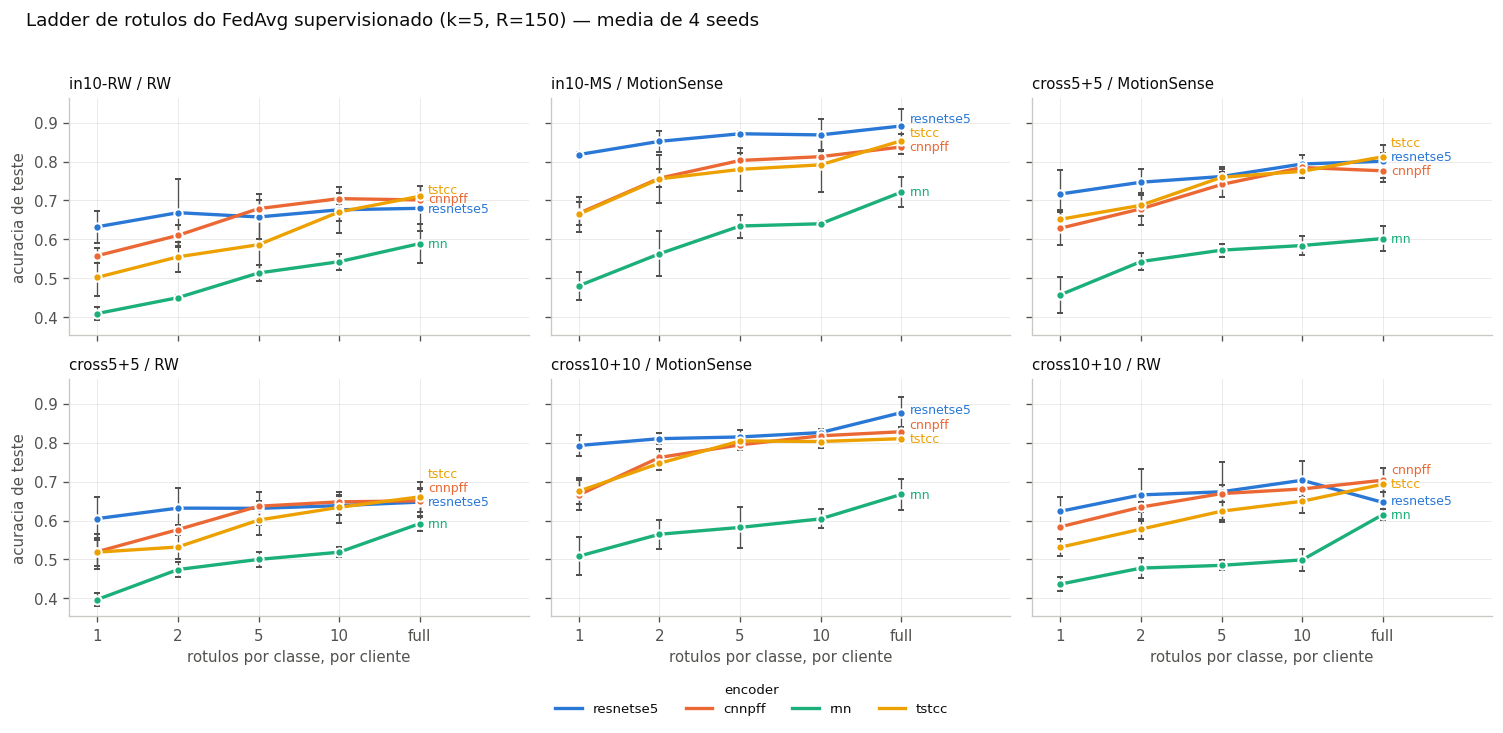

In [5]:
def plot_ladder(ab):
    if ab.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    pairs = [(a, t) for a in ARM_ORDER
             for t in sorted(set(ab[ab.arm == a].target))]
    pairs = [p for p in pairs if not ab[(ab.arm == p[0]) & (ab.target == p[1])].empty]
    if not pairs:
        print('sem celula completa ainda — nada a plotar.')
        return
    ncol = min(3, len(pairs))
    nrow = int(np.ceil(len(pairs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow),
                             squeeze=False, sharex=True, sharey=True)
    xs = np.arange(len(SHOT_ORDER))
    for ax, (arm, tgt) in zip(axes.ravel(), pairs):
        sub = ab[(ab.arm == arm) & (ab.target == tgt)]
        ends = []
        for enc in ENCODERS:
            s = sub[sub.encoder == enc]
            if s.empty:
                continue
            g = s.groupby('n_shots')['test_acc'].agg(['mean', 'std'])
            g = g.reindex([x for x in SHOT_ORDER if x in g.index])
            xi = [SHOT_ORDER.index(k) for k in g.index]
            ax.errorbar(xi, g['mean'], yerr=g['std'], lw=2, color=COLOR[enc],
                        marker='o', ms=5, mec='white', mew=1.2, capsize=2,
                        ecolor=INK_2, elinewidth=0.8, label=enc,
                        solid_capstyle='round')
            ends.append((xi[-1], g['mean'].iloc[-1], enc, COLOR[enc]))
        ax.set_title('%s / %s' % (arm, tgt.replace('RealWorld_thigh', 'RW')),
                     fontsize=9, color=INK, loc='left')
        ax.set_xticks(xs)
        ax.set_xticklabels(SHOT_ORDER)
        ax.set_xlim(-0.35, len(SHOT_ORDER) + 0.35)
        # Rotulo direto DEPOIS de fixar os limites, senao o empurrao vertical
        # e calculado sobre uma escala que ainda vai mudar.
        place_labels(ax, ends)
    for ax in axes.ravel()[len(pairs):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel('rotulos por classe, por cliente')
    for ax in axes[:, 0]:
        ax.set_ylabel('acuracia de teste')
    fig.suptitle('Ladder de rotulos do FedAvg supervisionado (k=5, R=150) — media de 4 seeds',
                 fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, COLOR, ENCODERS, 'encoder')
    fig.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()


plot_ladder(best)

## 5. Quanto cada degrau ainda deixa na mesa

Δ **pareado por seed** entre `full` e cada degrau, mesmo alvo e mesmo encoder. E a
folga que o Fed-SSL pode, no melhor caso, recuperar sem rotulo adicional: se em
`L=1` a folga e 20 pp, esse e o teto do que o pre-treino tem para ganhar ali.

Pareado, e nao diferenca de medias, porque as seeds sao as mesmas nos dois degraus
(a ladder e aninhada) — parear remove a variancia entre seeds do Δ.

In [6]:
def headroom(ab):
    # Δ pareado por seed: acc(full) - acc(L), por encoder/arm/alvo/degrau.
    if ab.empty:
        return pd.DataFrame()
    out = []
    for (enc, arm, tgt), s in ab.groupby(['encoder', 'arm', 'target']):
        ref = s[s.n_shots == 'full'].set_index('seed')['test_acc']
        if ref.empty:
            continue
        for shots in SHOT_ORDER[:-1]:
            x = s[s.n_shots == shots].set_index('seed')['test_acc']
            common = ref.index.intersection(x.index)
            if len(common) == 0:
                continue
            d = ref[common] - x[common]
            out.append({'encoder': enc, 'arm': arm,
                        'alvo': tgt.replace('RealWorld_thigh', 'RW'),
                        'n_shots': shots, 'acc_L': round(x[common].mean(), 3),
                        'acc_full': round(ref[common].mean(), 3),
                        'folga_pp': round(d.mean() * 100, 2),
                        'dp_pp': round(d.std() * 100, 2), 'n': len(common)})
    return pd.DataFrame(out)


hr = headroom(best)
if hr.empty:
    print('nenhum par de degraus completo ainda (falta o `full` ou o degrau few-shot).')
else:
    print('folga_pp = acuracia(full) - acuracia(L), pareada por seed.')
    print('E o teto do que o Fed-SSL pode recuperar naquele degrau.')
    piv = hr.pivot_table(index=['arm', 'alvo', 'encoder'], columns='n_shots',
                         values='folga_pp')
    piv = piv.reindex(columns=[s for s in SHOT_ORDER[:-1] if s in piv.columns])
    display(piv.round(2).style.set_caption('folga ate o `full`, em pontos percentuais'))

folga_pp = acuracia(full) - acuracia(L), pareada por seed.
E o teto do que o Fed-SSL pode recuperar naquele degrau.


## 6. Transferencia entre dominios

### 6.1 Os dois contrastes

Dois Δ, ambos **pareados por seed** contra o braco in-domain do **mesmo alvo**, e
medidos em **cada degrau** da ladder:

| contraste | Δ | o que isola |
|---|---|---|
| **diluicao** | `cross5+5 − in10-<ds>` | mesmos 10 clientes, metade trocada por clientes do outro dataset. Numero de clientes, janelas por cliente e orcamento identicos — muda **so** a composicao de dominio |
| **aumento** | `cross10+10 − in10-<ds>` | os 10 clientes do alvo **mais** 10 estrangeiros. Confunde dominio com volume, de proposito |

A **diluicao** e o contraste limpo: nao confunde dominio com quantidade de dado. O
**aumento** confunde os dois porque e a pergunta operacional — "vale recrutar
usuarios de outro dataset?" — e la o volume faz parte da resposta, nao e um
confundidor a remover.

O notebook irmao (`cross_device_avaliation.ipynb`, secao 6) mede a diluicao **so
no degrau `full`**. O que esta secao acrescenta e o **eixo de rotulo**: se o custo
de misturar dominios muda com a escassez de rotulo, o desenho do braco Fed-SSL
muda com ele. O braco `cross10+10` nao era contrastado em nenhum dos dois.

> ⚠️ **Ressalva de selecao, e ela importa aqui.** A rodada dos bracos `cross*` e
> escolhida pela media de `val_acc` sobre os **dois** alvos — e um modelo unico
> servindo os dois dominios; a dos bracos in-domain, pelo alvo unico. Entao o Δ por
> alvo carrega uma rodada escolhida em parte pelo **outro** dominio. Isso nao e
> artefato a corrigir: e a diferenca entre *o modelo que eu implantaria para os
> dois* e *o modelo especializado num*. Ler o Δ como **custo de servir dois
> dominios com um modelo**, nao como perda de capacidade do encoder.
>
> Vale tambem o aviso F7 da abertura: nos degraus baixos a selecao usa o split de
> validacao inteiro, entao **os dois lados do Δ** estao otimistas. O Δ sofre menos
> que o nivel absoluto, porque o vies atua nas duas pontas, mas nao e imune.

In [7]:
IN_ARM = {'RealWorld_thigh': 'in10-RW', 'MotionSense': 'in10-MS'}
CROSS_ARMS = {'cross5+5': 'diluicao', 'cross10+10': 'aumento'}


def paired_vs_indomain(ab, cross_arm, metric='test_acc'):
    """Δ pareado por seed: `cross_arm` - in-domain do mesmo alvo, por degrau.

    Pareado, e nao diferenca de medias, porque a mesma seed define o mesmo
    recorte de rotulo nos dois bracos — parear remove a variancia entre seeds,
    que aqui e da ordem do proprio efeito.
    """
    if ab.empty:
        return pd.DataFrame()
    out = []
    for (enc, tgt, shots), s in ab.groupby(['encoder', 'target', 'n_shots']):
        ia = IN_ARM.get(tgt)
        x = s[s.arm == cross_arm].set_index('seed')[metric]
        y = s[s.arm == ia].set_index('seed')[metric]
        common = x.index.intersection(y.index)
        if len(common) == 0:
            continue
        d = (x[common] - y[common]) * 100
        out.append({'contraste': CROSS_ARMS[cross_arm], 'encoder': enc,
                    'alvo': tgt.replace('RealWorld_thigh', 'RW'),
                    'n_shots': shots,
                    'cross_pp': round(x[common].mean() * 100, 1),
                    'in_pp': round(y[common].mean() * 100, 1),
                    'delta_pp': round(d.mean(), 2), 'dp_pp': round(d.std(), 2),
                    'n': len(common)})
    return pd.DataFrame(out)


def transfer_frame(ab, metric='test_acc'):
    fr = [paired_vs_indomain(ab, a, metric) for a in CROSS_ARMS]
    fr = [f for f in fr if not f.empty]
    return pd.concat(fr, ignore_index=True) if fr else pd.DataFrame()


tr = transfer_frame(best)
if tr.empty:
    print('nenhum par cross/in-domain completo ainda.')
else:
    for arm, nome in CROSS_ARMS.items():
        sub = tr[tr.contraste == nome]
        piv = sub.pivot_table(index=['alvo', 'encoder'], columns='n_shots',
                              values='delta_pp')
        piv = piv.reindex(columns=[s for s in SHOT_ORDER if s in piv.columns])
        piv = piv.reindex(index=[(a, e) for a in ['RW', 'MotionSense']
                                 for e in ENCODERS if (a, e) in piv.index])
        display(piv.round(2).style.set_caption(
            'Δ %s (%s - in-domain), pp de acuracia — negativo = misturar custa'
            % (nome, arm)))
    # Sem esta checagem a tabela acima convida a ler celula por celula, que e
    # exatamente o que 4 seeds nao sustentam.
    print('dp do Δ pareado por celula: mediana %.1f pp, maximo %.1f pp.'
          % (tr.dp_pp.median(), tr.dp_pp.max()))
    print('celulas cujo |Δ| excede o proprio dp: %d de %d — as outras estao no ruido,'
          % (int((tr.delta_pp.abs() > tr.dp_pp).sum()), len(tr)))
    print('e a leitura tem de ser feita nas marginais da 6.2, nao celula a celula.')

dp do Δ pareado por celula: mediana 3.4 pp, maximo 9.1 pp.
celulas cujo |Δ| excede o proprio dp: 38 de 80 — as outras estao no ruido,
e a leitura tem de ser feita nas marginais da 6.2, nao celula a celula.


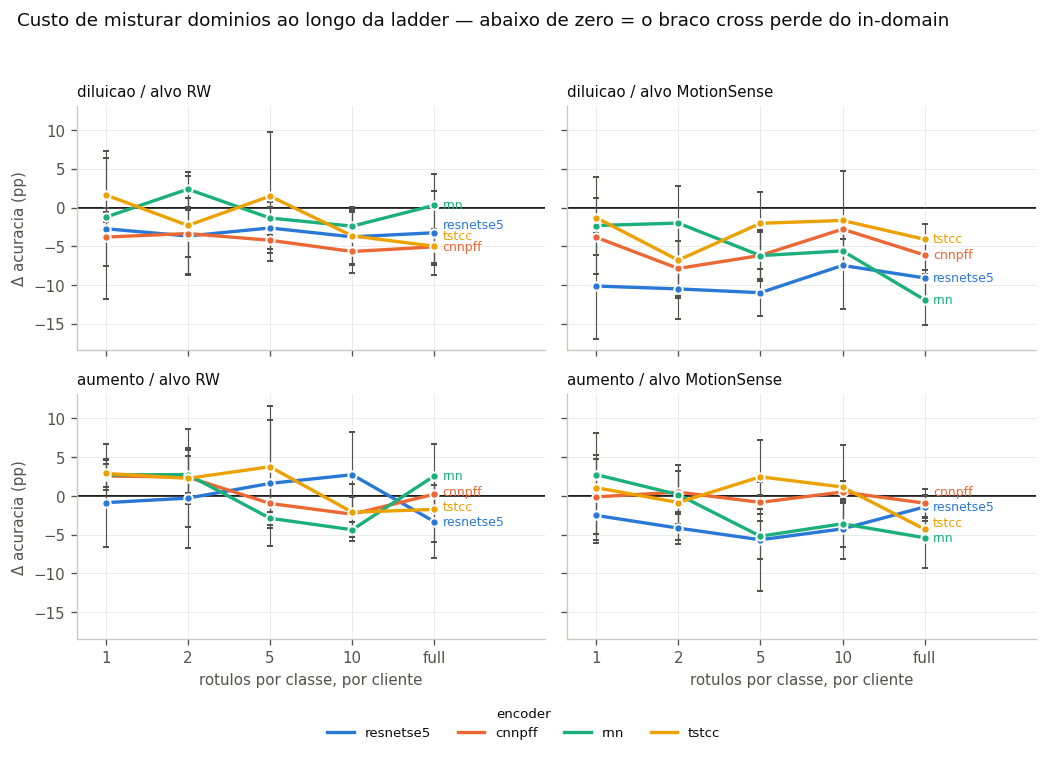

In [8]:
def plot_transfer(tr):
    # Uma linha por encoder, x = degrau (ordinal), y = Δ pp. Linha de zero em
    # destaque: e a referencia que da sentido ao sinal, e nao apenas mais uma
    # grade. Painel por (contraste, alvo) — 2x2 — com sharey para que a
    # comparacao entre diluicao e aumento seja de MAGNITUDE, nao so de forma.
    if tr.empty:
        print('sem Δ completo ainda — nada a plotar.')
        return
    alvos = [a for a in ['RW', 'MotionSense'] if a in set(tr.alvo)]
    contr = [c for c in CROSS_ARMS.values() if c in set(tr.contraste)]
    if not alvos or not contr:
        return
    fig, axes = plt.subplots(len(contr), len(alvos),
                             figsize=(4.4 * len(alvos), 3.1 * len(contr)),
                             squeeze=False, sharex=True, sharey=True)
    for i, cnome in enumerate(contr):
        for j, alvo in enumerate(alvos):
            ax = axes[i][j]
            sub = tr[(tr.contraste == cnome) & (tr.alvo == alvo)]
            ax.axhline(0, color=INK, lw=1.1, zorder=1)
            ends = []
            for enc in ENCODERS:
                s = sub[sub.encoder == enc]
                if s.empty:
                    continue
                g = s.set_index('n_shots')[['delta_pp', 'dp_pp']]
                g = g.reindex([x for x in SHOT_ORDER if x in g.index])
                xi = [SHOT_ORDER.index(k) for k in g.index]
                ax.errorbar(xi, g.delta_pp, yerr=g.dp_pp, lw=2, color=COLOR[enc],
                            marker='o', ms=5, mec='white', mew=1.2, capsize=2,
                            ecolor=INK_2, elinewidth=0.7, label=enc, zorder=2,
                            solid_capstyle='round')
                ends.append((xi[-1], g.delta_pp.iloc[-1], enc, COLOR[enc]))
            ax.set_title('%s / alvo %s' % (cnome, alvo), fontsize=9,
                         color=INK, loc='left')
            ax.set_xticks(np.arange(len(SHOT_ORDER)))
            ax.set_xticklabels(SHOT_ORDER)
            ax.set_xlim(-0.35, len(SHOT_ORDER) + 0.35)
            place_labels(ax, ends)
    for ax in axes[-1]:
        ax.set_xlabel('rotulos por classe, por cliente')
    for row in axes:
        row[0].set_ylabel('Δ acuracia (pp)')
    fig.suptitle('Custo de misturar dominios ao longo da ladder — abaixo de zero = '
                 'o braco cross perde do in-domain',
                 fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, COLOR, ENCODERS, 'encoder')
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_transfer(tr)

### 6.2 Degradacao por encoder e por dataset

As marginais do Δ. Tres perguntas distintas, e a terceira e a que interessa ao
Fed-SSL:

1. **Qual encoder aguenta melhor a mistura?** Se a ordem dos encoders muda a cada
   degrau, nao ha ordenacao a reportar — e ruido de amostragem com 4 seeds.
2. **Os dois datasets sofrem igual?** Uma assimetria forte diz que "custo de
   domain shift" nao e um numero unico: depende de qual lado voce esta servindo.
3. **O custo cresce ou encolhe com mais rotulo?** Esta e a pergunta que muda o
   desenho do braco Fed-SSL. Se misturar dominios custa **menos** no degrau baixo,
   dado estrangeiro e mais util justamente onde o rotulo falta — que e a hipotese
   que o pre-treino federado explora.

In [9]:
def degradation_summary(tr):
    """Marginais do Δ: por encoder, por alvo e por degrau.

    Marginal, e nao a celula individual, porque com 4 seeds o dp por celula e da
    ordem do proprio Δ (ver a checagem impressa na 6.1). A media sobre 8 celulas
    de um encoder ou 16 de um degrau e o que sustenta ordenacao; a celula
    individual, sozinha, nao sustenta.
    """
    if tr.empty:
        return {}
    out = {}
    for eixo, col in [('por encoder', 'encoder'), ('por alvo', 'alvo'),
                      ('por degrau', 'n_shots')]:
        t = tr.pivot_table(index=col, columns='contraste', values='delta_pp',
                           aggfunc='mean').round(2)
        if col == 'n_shots':
            t = t.reindex([s for s in SHOT_ORDER if s in t.index])
        elif col == 'encoder':
            t = t.reindex([e for e in ENCODERS if e in t.index])
        out[eixo] = t
    return out


if tr.empty:
    print('sem Δ para resumir.')
else:
    summ = degradation_summary(tr)
    for eixo, t in summ.items():
        display(t.style.set_caption('Δ medio %s (pp de acuracia)' % eixo))

    dil = tr[tr.contraste == 'diluicao']
    rank = dil.groupby('encoder').delta_pp.mean().sort_values()
    print('Robustez a diluicao de dominio (menos negativo = mais robusto):')
    print('  ' + ' < '.join('%s (%.1f pp)' % (e, v) for e, v in rank.items()))

    # A ordenacao vale se ela se mantem ao longo da ladder; se cada degrau da uma
    # ordem diferente, "encoder X e mais robusto" e ruido de amostragem.
    per_shot = dil.pivot_table(index='encoder', columns='n_shots',
                               values='delta_pp', aggfunc='mean')
    per_shot = per_shot.reindex(columns=[s for s in SHOT_ORDER if s in per_shot.columns])
    ordens = {c: tuple(per_shot[c].sort_values().index) for c in per_shot.columns}
    print('\nOrdem dos encoders por degrau (a ordenacao acima so vale se for estavel):')
    for c, o in ordens.items():
        print('  L=%-5s %s' % (c, ' < '.join(o)))
    print('  ordens distintas: %d de %d degraus' % (len(set(ordens.values())), len(ordens)))

contraste,aumento,diluicao
encoder,,
resnetse5,-1.810000,-6.420000
cnnpff,0.100000,-4.890000
rnn,-1.040000,-3.030000
tstcc,0.460000,-2.370000


contraste,aumento,diluicao
alvo,,
MotionSense,-1.530000,-5.940000
RW,0.390000,-2.420000


contraste,aumento,diluicao
n_shots,,
1,1.060000,-2.960000
2,0.350000,-4.260000
5,-0.960000,-4.010000
10,-1.530000,-4.120000
full,-1.780000,-5.530000


Robustez a diluicao de dominio (menos negativo = mais robusto):
  resnetse5 (-6.4 pp) < cnnpff (-4.9 pp) < rnn (-3.0 pp) < tstcc (-2.4 pp)

Ordem dos encoders por degrau (a ordenacao acima so vale se for estavel):
  L=1     resnetse5 < cnnpff < rnn < tstcc
  L=2     resnetse5 < cnnpff < tstcc < rnn
  L=5     resnetse5 < cnnpff < rnn < tstcc
  L=10    resnetse5 < cnnpff < rnn < tstcc
  L=full  resnetse5 < rnn < cnnpff < tstcc
  ordens distintas: 3 de 5 degraus


### 6.3 Feature skew — o outro eixo de heterogeneidade, e so no `full`

Os bracos `iid:*` nao existem nesta grade, mas existem na grade fechada de
`20449ab`, no degrau `full`. Vale traze-los aqui por uma razao de leitura: sem eles
nao ha como dizer se o custo medido acima e **dominio** ou apenas
**heterogeneidade de particao**.

O par `device` vs `iid` mantem dataset, numero de clientes, janelas por cliente e
distribuicao de classes identicos — muda **so** se a fronteira entre clientes
coincide com a fronteira entre pessoas. E o controle limpo do feature skew.

> Este contraste existe **so no degrau `full`**. Nao ha versao few-shot dele, e
> nada aqui autoriza extrapolar o skew de particao para os degraus baixos.

In [10]:
IID_ALIAS = {'iid:RealWorld_thigh:10': 'iid-RW', 'iid:MotionSense:10': 'iid-MS'}
SKEW_PAIRS = [('in10-RW', 'iid-RW', 'RealWorld_thigh'),
              ('in10-MS', 'iid-MS', 'MotionSense')]


def load_skew_full():
    """Bracos `device` e `iid` no degrau `full`, da grade fechada de `20449ab`.

    Loader proprio, e nao o `load_full_point()`, porque aquele filtra
    `spec.isin(ALIAS)` — o que exclui os `iid` de proposito, ja que eles nao
    existem na ladder. Aqui eles entram, e SO no degrau `full`: e por isso que
    esta subsecao nao tem eixo de rotulo, ao contrario das anteriores.
    """
    files = sorted(OLD_PART_DIR.glob('*.csv'))
    if not files:
        return pd.DataFrame()
    alias = dict(ALIAS, **IID_ALIAS)
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df = df[(df.local_epochs == LOCAL_EPOCHS) & df.spec.isin(alias)].copy()
    df['arm'] = df.spec.map(alias)
    df['n_shots'] = 'full'
    df['method'] = 'none'
    return df.dropna(subset=['val_acc'])


def skew_delta(metric='test_acc'):
    # Reusa complete_only/at_best: KEYS ja inclui `arm` e `n_shots`, entao a regra
    # das 4 seeds e a selecao pela validacao valem aqui sem adaptacao.
    raw_sk = load_skew_full()
    if raw_sk.empty:
        return pd.DataFrame()
    ab_sk = at_best(complete_only(raw_sk))
    out = []
    for dev_arm, iid_arm, tgt in SKEW_PAIRS:
        s = ab_sk[ab_sk.target == tgt]
        for enc in ENCODERS:
            x = s[(s.arm == dev_arm) & (s.encoder == enc)].set_index('seed')[metric]
            y = s[(s.arm == iid_arm) & (s.encoder == enc)].set_index('seed')[metric]
            common = x.index.intersection(y.index)
            if len(common) == 0:
                continue
            d = (x[common] - y[common]) * 100
            out.append({'alvo': tgt.replace('RealWorld_thigh', 'RW'),
                        'encoder': enc,
                        'device_pp': round(x[common].mean() * 100, 1),
                        'iid_pp': round(y[common].mean() * 100, 1),
                        'delta_pp': round(d.mean(), 2), 'dp_pp': round(d.std(), 2),
                        'n': len(common)})
    return pd.DataFrame(out)


sk = skew_delta()
if sk.empty:
    print('bracos iid indisponiveis — sem contraste de feature skew.')
else:
    display(sk.set_index(['alvo', 'encoder']).style.set_caption(
        'Δ feature skew (device - iid) no degrau `full`, pp de acuracia'))
    print('media por alvo:', sk.groupby('alvo').delta_pp.mean().round(2).to_dict())
    print('celulas com |Δ| > dp: %d de %d — com n=4 seeds, o resto esta no ruido.'
          % (int((sk.delta_pp.abs() > sk.dp_pp).sum()), len(sk)))
    print()
    print('Comparar com a magnitude da diluicao de dominio da 6.1: se o skew de')
    print('particao e menor que a troca de dataset, o eixo que o Fed-SSL precisa')
    print('atacar e o dominio, nao a heterogeneidade entre pessoas.')

media por alvo: {'MotionSense': -0.4, 'RW': -3.05}
celulas com |Δ| > dp: 3 de 8 — com n=4 seeds, o resto esta no ruido.

Comparar com a magnitude da diluicao de dominio da 6.1: se o skew de
particao e menor que a troca de dataset, o eixo que o Fed-SSL precisa
atacar e o dominio, nao a heterogeneidade entre pessoas.


## 7. Custo de comunicacao

`uplink_mb` e por rodada, ja somado sobre os clientes. Duas leituras, e elas
respondem perguntas diferentes:

1. **Custo fixo por rodada** — depende do tamanho do modelo e do numero de
   clientes, e **nao depende do degrau da ladder**: o que a ladder muda e quantas
   amostras entram na CrossEntropy local, nao quantos parametros trafegam. Se a
   barra de um encoder e alta, ela e alta em todos os degraus.
2. **Custo acumulado ate a rodada escolhida** — o que o braco efetivamente gastou
   para chegar ao numero reportado. Este varia com o degrau, porque a validacao
   escolhe rodadas diferentes.

A segunda leitura e o eixo em que o Fed-SSL tera de ser comparado tambem, e ela e
dura com ele: o braco Fed-SSL gasta **rodadas de pre-treino que o baseline nao
gasta**. Comparar "Fed-SSL apos R_pre + r rodadas" com "FedAvg apos r rodadas"
seria dar comunicacao de graca ao Fed-SSL.

In [11]:
def comm_cost(ab):
    if ab.empty:
        return pd.DataFrame()
    one = ab.drop_duplicates(subset=KEYS)
    one = one.assign(total_uplink_gb=one.uplink_mb * one.best_round / 1024)
    t = one.groupby(['encoder', 'arm', 'n_shots']).agg(
        rodada=('best_round', 'mean'),
        mb_por_rodada=('uplink_mb', 'first'),
        uplink_ate_selecao_gb=('total_uplink_gb', 'mean')).reset_index()
    t['n_shots'] = pd.Categorical(t.n_shots, SHOT_ORDER, ordered=True)
    return t.sort_values(['arm', 'encoder', 'n_shots']).round(2)


cc = comm_cost(best)
if cc.empty:
    print('sem celula completa ainda.')
else:
    display(cc.set_index(['arm', 'encoder', 'n_shots']))
    # Checagem da afirmacao 1 do texto acima, contra o dado.
    spread = cc.groupby(['encoder', 'arm'])['mb_por_rodada'].nunique()
    print('MB/rodada distintos por (encoder, arm) ao longo da ladder: %s'
          % sorted(set(spread.values)))
    print('(1 = confirmado: o degrau nao muda o custo por rodada)')

rodada  mb_por_rodada  uplink_ate_selecao_gb
arm        encoder n_shots                                              
cross10+10 cnnpff  1        113.25          11.13                   1.23
                   2        133.75          11.13                   1.45
                   5        137.25          11.13                   1.49
                   10       119.25          11.13                   1.30
                   full     140.25          11.13                   1.52
...                            ...            ...                    ...
in10-RW    tstcc   1         64.50         127.09                   8.01
                   2         86.00         127.09                  10.67
                   5         72.25         127.09                   8.97
                   10       124.25         127.09                  15.42
                   full      95.25         127.09                  11.82

[80 rows x 3 columns]

MB/rodada distintos por (encoder, arm) ao longo da ladder: [np.int64(1)]
(1 = confirmado: o degrau nao muda o custo por rodada)


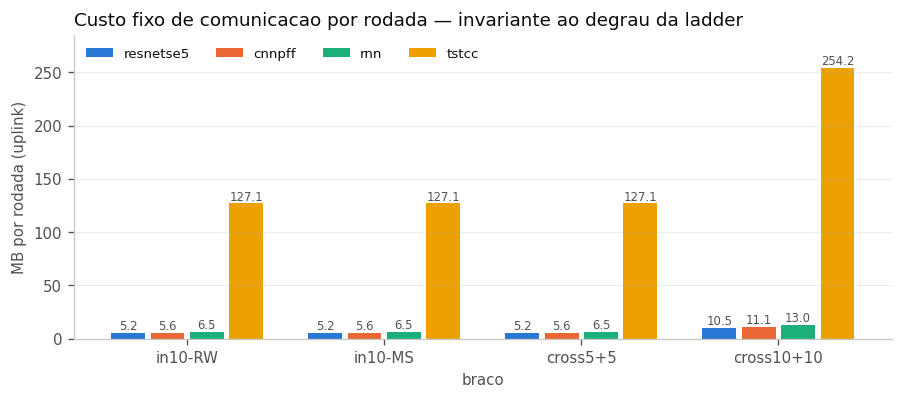

In [12]:
def plot_comm_bars(ab):
    # Leitura 1: custo fixo por rodada. Barras agrupadas, cor = encoder.
    # Como o degrau nao altera este numero, uma barra por (arm, encoder) basta.
    # Escala LINEAR de proposito: o comprimento da barra tem de ser proporcional
    # ao valor, e a distancia de uma ordem de grandeza entre o tstcc e os outros
    # E o achado. A leitura fina dos tres pequenos vem do rotulo de valor.
    if ab.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    cc = comm_cost(ab)
    g = cc.groupby(['arm', 'encoder'])['mb_por_rodada'].first().unstack()
    arms = [a for a in ARM_ORDER if a in g.index]
    encs = [e for e in ENCODERS if e in g.columns]
    if not arms or not encs:
        return
    g = g.reindex(index=arms, columns=encs)
    fig, ax = plt.subplots(figsize=(7.6, 3.4))
    x = np.arange(len(arms))
    w = 0.8 / len(encs)
    for j, enc in enumerate(encs):
        off = (j - (len(encs) - 1) / 2) * w
        # width * 0.86 deixa o vao de superficie entre barras adjacentes.
        bars = ax.bar(x + off, g[enc].values, width=w * 0.86, color=COLOR[enc],
                      label=enc)
        for b, v in zip(bars, g[enc].values):
            if np.isfinite(v):
                ax.annotate('%.1f' % v, (b.get_x() + b.get_width() / 2, v),
                            xytext=(0, 2), textcoords='offset points',
                            ha='center', fontsize=7, color=INK_2)
    ax.set_xticks(x)
    ax.set_xticklabels(arms)
    ax.set_ylabel('MB por rodada (uplink)')
    ax.set_xlabel('braco')
    ax.margins(y=0.12)
    ax.legend(loc='upper left', ncol=len(encs), fontsize=8)
    ax.grid(axis='x', alpha=0)
    ax.set_title('Custo fixo de comunicacao por rodada — invariante ao degrau da ladder',
                 fontsize=11, loc='left', color=INK)
    fig.tight_layout()
    plt.show()


plot_comm_bars(best)

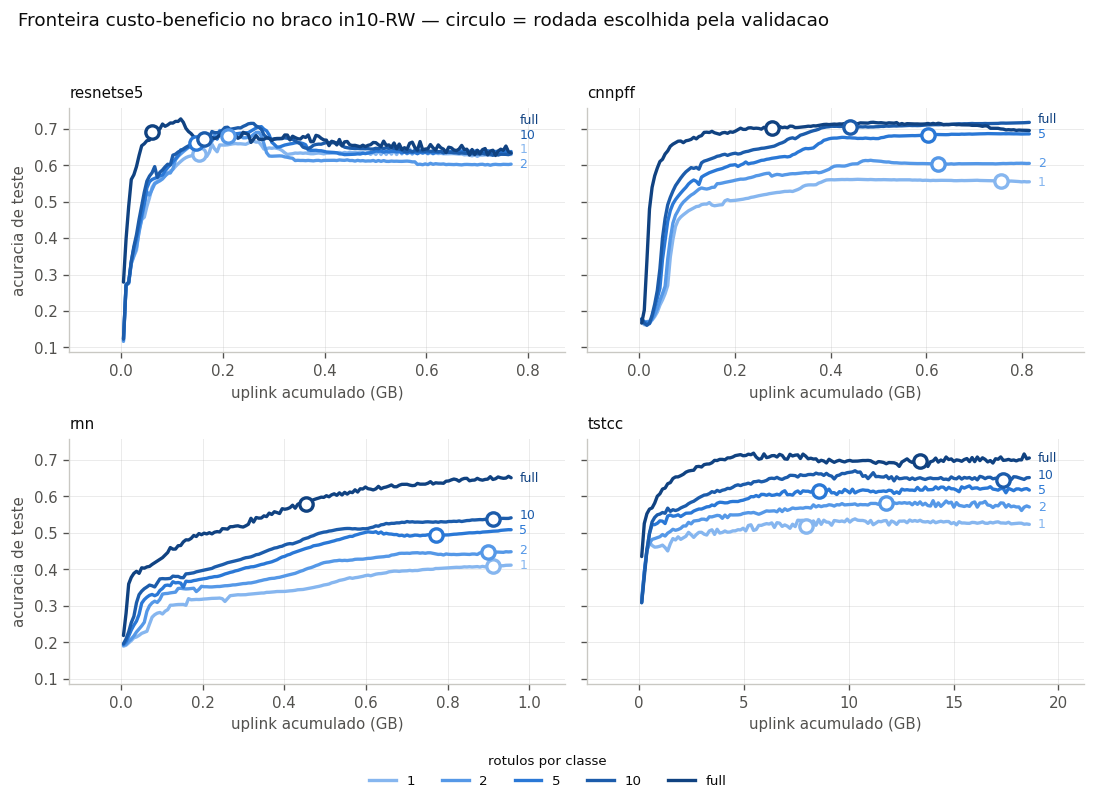

In [13]:
def plot_comm_frontier(df, ab, arm=ARM_FRONTIER):
    # Leitura 2: fronteira custo-beneficio. Trajetoria ao longo das rodadas —
    # x = uplink acumulado, y = acuracia de teste. Uma linha por degrau (rampa
    # ORDINAL, porque rotulo e magnitude ordenada), um painel por encoder.
    # E linha, nao scatter: a serie percorre as rodadas, entao a lista de pares
    # de cor relevante e a de vizinhos, onde a paleta valida.
    # sharex=False de proposito: o tstcc gasta ~25x mais MB/rodada que os outros
    # (ver a figura anterior), entao um eixo x comum espreme os outros tres
    # paineis num tico e a fronteira deles fica ilegivel. O que se compara DENTRO
    # de um painel sao os degraus; a comparacao ENTRE encoders e a das barras.
    sub = df[df.arm == arm]
    if sub.empty:
        print('sem dado completo para o braco %s ainda.' % arm)
        return
    encs = [e for e in ENCODERS if e in set(sub.encoder)]
    ncol = min(2, len(encs))
    nrow = int(np.ceil(len(encs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.3 * nrow),
                             squeeze=False, sharex=False, sharey=True)
    sel = ab[ab.arm == arm].drop_duplicates(subset=KEYS)
    for ax, enc in zip(axes.ravel(), encs):
        s = sub[sub.encoder == enc]
        ends = []
        for shots in SHOT_ORDER:
            t = s[s.n_shots == shots]
            if t.empty:
                continue
            curve = t.groupby('round').agg(acc=('test_acc', 'mean'),
                                           mb=('uplink_mb', 'first'))
            gb = curve.mb * curve.index / 1024
            ax.plot(gb, curve.acc, lw=2, color=SHOT_COLOR[shots],
                    label=shots, solid_capstyle='round')
            # Marcador vazado = rodada escolhida pela validacao.
            br = sel[(sel.encoder == enc) & (sel.n_shots == shots)]
            if not br.empty:
                r = int(br.best_round.median())
                if r in curve.index:
                    ax.plot([curve.mb.iloc[0] * r / 1024], [curve.acc[r]],
                            marker='o', ms=8, mfc='white',
                            mec=SHOT_COLOR[shots], mew=2, zorder=5)
            ends.append((gb.iloc[-1], curve.acc.iloc[-1], shots, SHOT_COLOR[shots]))
        ax.set_title(enc, fontsize=9, color=INK, loc='left')
        ax.margins(x=0.14)
        place_labels(ax, ends)
    for ax in axes.ravel()[len(encs):]:
        ax.set_visible(False)
    for ax in axes.ravel()[:len(encs)]:
        ax.set_xlabel('uplink acumulado (GB)')
    for ax in axes[:, 0]:
        ax.set_ylabel('acuracia de teste')
    fig.suptitle('Fronteira custo-beneficio no braco %s — circulo = rodada escolhida pela validacao'
                 % arm, fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, SHOT_COLOR, SHOT_ORDER, 'rotulos por classe')
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_comm_frontier(full, best)

## 8. Leitura

Preencher conforme a grade fecha. Perguntas que este notebook responde:

1. **Onde a ladder satura?** Secao 4 — o degrau em que a curva achata e o teto do
   que rotulo adicional compra, e o piso do que o Fed-SSL precisa bater.
2. **Quanta folga existe em cada degrau?** Secao 5 — `folga_pp` e o maximo que o
   pre-treino pode recuperar sem rotulo novo. Folga pequena em `L=10` significa
   que o Fed-SSL so tem espaco nos degraus baixos.
3. **Quanto custa misturar dominios, e isso muda com o rotulo?** Secao 6.1/6.2 —
   se a diluicao custa **menos** nos degraus baixos, dado estrangeiro e mais util
   justamente onde o rotulo falta, e isso e argumento a favor do pre-treino
   federado no braco `cross`. Se custa **mais**, o Fed-SSL tera de justificar o
   braco cross por outro caminho.
4. **O custo e do dominio ou da particao?** Secao 6.3 — a magnitude do
   `device − iid` (feature skew) contra a da diluicao de dominio. Se o skew de
   particao e a menor das duas, o eixo a atacar e o dominio.
5. **A ordenacao dos encoders por robustez e real?** Secao 6.2 — se a ordem muda a
   cada degrau, nao ha ordenacao a reportar.
6. **Quanto custa cada ponto de acuracia?** Secao 7 — e o eixo em que a comparacao
   com o Fed-SSL e mais dura, porque o pre-treino gasta rodadas a mais.
7. **`R=150` bastou nos degraus baixos?** Secao 3 — `no_teto > 0` num degrau
   significa que aquele numero e um piso.

### O que este notebook nao responde

- **Nao ha Fed-SSL aqui.** Este e o contrafactual, medido sozinho. A comparacao
  entra em notebook proprio quando a Fase 2 do braco Fed-SSL existir.
- **O feature skew existe so no degrau `full`.** Os bracos `iid:*` nao foram
  rodados nesta grade (ablacao de segunda onda); a secao 6.3 os le da grade fechada
  de `20449ab`, onde existe apenas o shard inteiro. Nao ha versao few-shot do
  contraste, e nada autoriza extrapola-lo para os degraus baixos.
- **A direcao da transferencia nao e desemaranhada da selecao.** O Δ dos bracos
  `cross*` carrega uma rodada escolhida pela media dos dois alvos (ver a ressalva
  em 6.1). Separar "custo de dominio" de "custo de servir dois alvos com um
  criterio de selecao" exigiria uma grade com selecao por alvo, que nao existe.
- **O F7 nao esta corrigido, esta declarado.** Ver o aviso na abertura: a selecao
  usa o split de validacao inteiro em todos os degraus, o que torna os degraus
  baixos otimistas. Qualquer leitura de "desempenho com 1 rotulo por classe" tem
  de carregar essa ressalva.

---

## 9. À prova: federações supervisionadas são prejudicadas sob domain shift?

Esta é a hipótese que serve de **pilar** ao trabalho — se ela não valer, não há problema
para o Fed-SSL atacar. Ela é bem estabelecida na literatura; o objetivo aqui não é
descobri-la, é **medi-la nesta base**, para que o resto se apoie em número próprio.

A Seção 6 já produz os dois Δ. Esta seção os transforma em **teste**: nomeia qual
hipótese nula cada contraste refuta, confronta o resultado com uma medida independente
de distância entre domínios, e — o que só este notebook pode fazer — pergunta **como o
custo do shift varia com o orçamento de rótulos**.

### 9.1 O que cada contraste refuta

| contraste | hipótese nula que ele testa | o que uma queda prova |
|---|---|---|
| **diluição** `cross5+5 − in10` | *os domínios são intercambiáveis* — uma janela do MotionSense vale o que vale uma do RealWorld. Mesmo nº de clientes, mesmo orçamento por cliente, mesmo total: sob a nula, trocar metade não muda nada | **existe shift** |
| **aumento** `cross10+10 − in10` | *dado estrangeiro, mesmo valendo menos, ainda soma*. O dado próprio fica **intacto** e entram 1.920 janelas rotuladas por cima | **transferência negativa** — rótulos a mais que pioram o modelo |

São a mesma afirmação em duas intensidades. A diluição é a mais fácil de refutar; o
aumento é a mais forte, porque exige que o dado estrangeiro seja **ativamente nocivo**,
não apenas menos útil.

*(O notebook irmão `cross_device_avaliation.ipynb` §9 mede os mesmos dois contrastes no
degrau `full`. Enquadramento idêntico — o que muda aqui é a ladder.)*

### 9.2 A pergunta que só esta grade responde

> **O domain shift machuca mais quando faltam rótulos?**

A intuição diz que sim: menos rótulos, menos capacidade de compensar a heterogeneidade.
É essa intuição que costuma motivar SSL como remédio para shift — e é a premissa
implícita do braço Fed-SSL. A figura abaixo a testa diretamente.

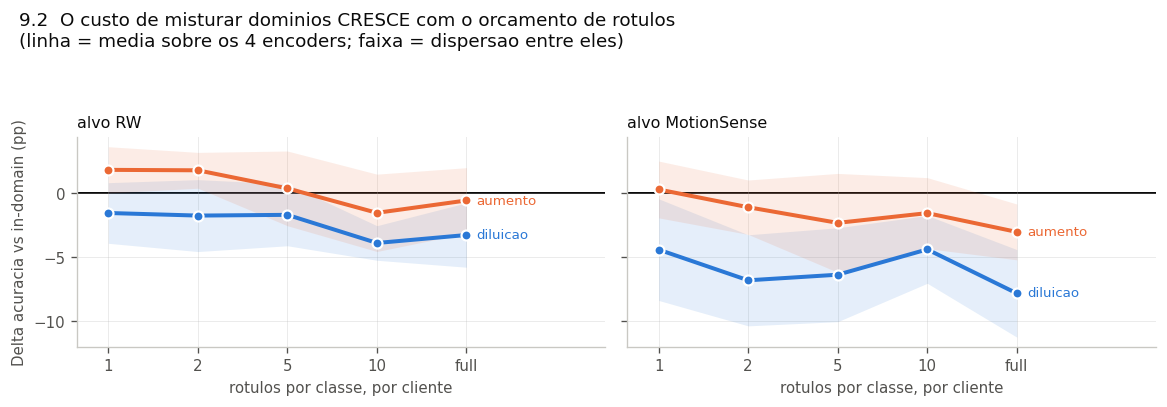

Δ medio (pp) por contraste x degrau, agregado sobre encoders e alvos:


n_shots,1,2,5,10,full
contraste,,,,,
aumento,1.1,0.4,-1.0,-1.5,-1.8
diluicao,-3.0,-4.3,-4.0,-4.1,-5.5


celulas negativas por degrau (de 8 = 4 encoders x 2 alvos):


n_shots,1,2,5,10,full
contraste,,,,,
aumento,3,3,5,5,6
diluicao,7,7,7,8,7


In [14]:
# Cor segue a ENTIDADE (o contraste). Par validado com os seis checks sob a lista de
# TODOS os pares: CVD dE 24.7, visao normal dE 33.6, contraste >= 3:1 — passa limpo.
# Nao reuso COLOR (encoders) aqui: a entidade destas figuras e o contraste, e a mesma
# cor nao pode significar `resnetse5` numa figura e `diluicao` na seguinte.
C_CONTR = {'diluicao': '#2a78d6', 'aumento': '#eb6834'}
ALVOS = ['RW', 'MotionSense']


def plot_custo_vs_rotulo(tr):
    """Marginal sobre encoders do Δ, ao longo da ladder. A faixa e a DISPERSAO
    entre encoders, nao um erro-padrao: ela diz o quanto o efeito depende da
    arquitetura, que e outra pergunta e nao deve ser lida como incerteza."""
    if tr.empty:
        print('sem Δ completo ainda.')
        return
    fig, axes = plt.subplots(1, len(ALVOS), figsize=(4.9 * len(ALVOS), 3.4),
                             sharey=True)
    xs = np.arange(len(SHOT_ORDER))
    for ax, alvo in zip(axes, ALVOS):
        ax.axhline(0, color=INK, lw=1.2, zorder=1)
        for nome, cor in C_CONTR.items():
            s = tr[(tr.contraste == nome) & (tr.alvo == alvo)]
            g = s.groupby('n_shots')['delta_pp'].agg(['mean', 'std'])
            g = g.reindex([x for x in SHOT_ORDER if x in g.index])
            xi = [SHOT_ORDER.index(k) for k in g.index]
            ax.plot(xi, g['mean'], lw=2.4, color=cor, marker='o', ms=6,
                    mec='white', mew=1.3, label=nome, zorder=3,
                    solid_capstyle='round')
            ax.fill_between(xi, g['mean'] - g['std'], g['mean'] + g['std'],
                            color=cor, alpha=0.12, lw=0, zorder=2)
            ax.annotate(nome, (xi[-1], g['mean'].iloc[-1]), xytext=(6, 0),
                        textcoords='offset points', fontsize=8, color=cor,
                        va='center')
        ax.set_xticks(xs)
        ax.set_xticklabels(SHOT_ORDER)
        ax.set_xlim(-0.35, len(SHOT_ORDER) + 0.55)
        ax.set_title('alvo %s' % alvo, fontsize=9.5, loc='left', color=INK)
        ax.set_xlabel('rotulos por classe, por cliente')
    axes[0].set_ylabel('Delta acuracia vs in-domain (pp)')
    fig.suptitle('9.2  O custo de misturar dominios CRESCE com o orcamento de rotulos\n'
                 '(linha = media sobre os 4 encoders; faixa = dispersao entre eles)',
                 fontsize=11, x=0.02, ha='left', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


plot_custo_vs_rotulo(tr)

marg = tr.pivot_table(index='contraste', columns='n_shots', values='delta_pp')
marg = marg.reindex(columns=[s for s in SHOT_ORDER if s in marg.columns])
print('Δ medio (pp) por contraste x degrau, agregado sobre encoders e alvos:')
display(marg.round(1))

sinal = (tr.groupby(['contraste', 'n_shots'])['delta_pp']
         .apply(lambda s: int((s < 0).sum())).unstack())
sinal = sinal.reindex(columns=[s for s in SHOT_ORDER if s in sinal.columns])
print('celulas negativas por degrau (de 8 = 4 encoders x 2 alvos):')
display(sinal)

### 9.3 Dose e resposta, degrau a degrau

Mostrar que a federação piora é metade do argumento. A outra metade é mostrar que ela
piora **na medida do shift** — se a queda for maior nos pares de domínio mais distantes,
a atribuição ao domínio deixa de ser inferência e passa a ser padrão.

Isso exige medir a distância entre domínios **sem usar estes runs**. A medida vem da
matriz de transfer supervisionada centralizada (`supervised_eval_transfer.csv`):

```
gap(encoder, alvo) = acc(treino no proprio dominio -> alvo)
                   - acc(treino no OUTRO dominio  -> alvo)
```

> **Por que isto não é o artefato de sempre.** Correlacionar o Δ federado contra um
> custo de shift medido *no próprio baseline federado* poria o mesmo termo nos dois
> eixos, e ruído puro já geraria correlação — foi assim que uma análise anterior deste
> projeto produziu um r = −0,70 que não significava nada. Aqui o `gap` vem de execuções
> **centralizadas**, sem nenhum run em comum com esta grade.

Com **n = 8** por degrau (4 encoders × 2 alvos), o intervalo de confiança de qualquer r
é larguíssimo. Os números descrevem a figura; não a testam.

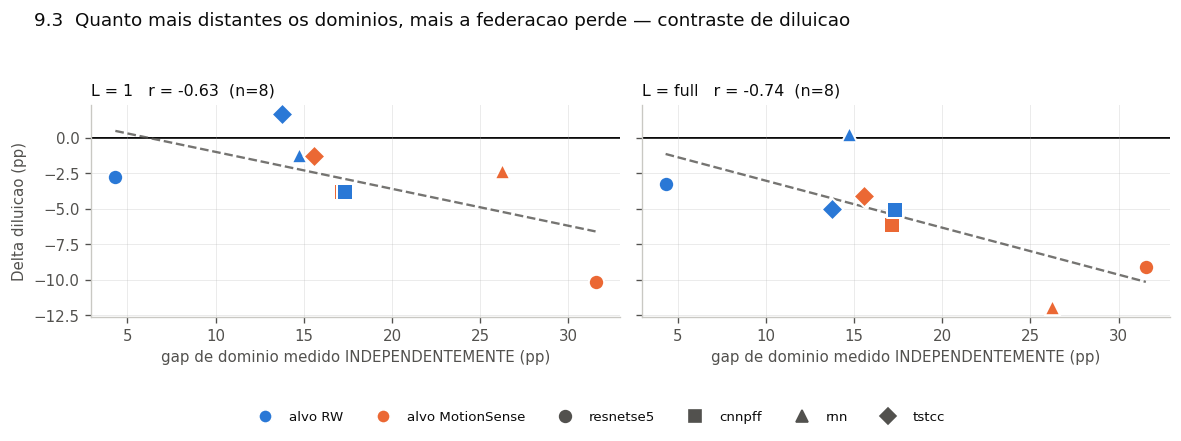

r(gap independente, Δ) por contraste x degrau — n=8 em cada célula.
Negativo = mais distancia entre dominios, mais perda federada.


,1,2,5,10,full
aumento,-0.18,-0.53,-0.78,-0.70,-0.10
diluicao,-0.63,-0.41,-0.76,-0.67,-0.74


In [15]:
SL_TRANSFER = PROJECT_ROOT / 'results' / 'supervised_eval_transfer.csv'
PAR_DS = ['RealWorld_thigh', 'MotionSense']
# Cor por ALVO e FORMA por encoder. Num scatter a lista de pares que vale e a de
# TODOS os pares, e ali a paleta de 4 encoders reprova (laranja x ambar, dE 13.7 <
# piso 15 da visao normal). Com 2 cores + forma, passa.
C_ALVO = {'RW': '#2a78d6', 'MotionSense': '#eb6834'}
MARCA = {'resnetse5': 'o', 'cnnpff': 's', 'rnn': '^', 'tstcc': 'D'}


def gap_independente():
    """Distancia entre dominios medida em runs CENTRALIZADOS — eixo independente."""
    t = pd.read_csv(SL_TRANSFER)
    t = t[t.n_shots.astype(str) == 'full']
    m = (t[t.source.isin(PAR_DS) & t.target.isin(PAR_DS)]
         .groupby(['encoder', 'source', 'target'])['test_acc'].mean() * 100)
    rows = []
    for tgt in PAR_DS:
        outro = [d for d in PAR_DS if d != tgt][0]
        for enc in ENCODERS:
            rows.append({'encoder': enc,
                         'alvo': tgt.replace('RealWorld_thigh', 'RW'),
                         'gap': m.loc[(enc, tgt, tgt)] - m.loc[(enc, outro, tgt)]})
    return pd.DataFrame(rows)


dose = tr.merge(gap_independente(), on=['encoder', 'alvo'])


def plot_dose(dose, contraste='diluicao', degraus=('1', 'full')):
    """Scatter nos degraus extremos — o meio esta na tabela de r logo abaixo."""
    fig, axes = plt.subplots(1, len(degraus), figsize=(4.9 * len(degraus), 3.5),
                             sharex=True, sharey=True)
    for ax, sh in zip(np.atleast_1d(axes), degraus):
        s = dose[(dose.contraste == contraste) & (dose.n_shots == sh)]
        for _, r in s.iterrows():
            ax.scatter(r.gap, r.delta_pp, s=85, color=C_ALVO[r.alvo],
                       marker=MARCA[r.encoder], ec='white', lw=1.2, zorder=3)
        rr = np.corrcoef(s.gap, s.delta_pp)[0, 1] if len(s) > 2 else np.nan
        if len(s) > 2:
            xs = np.linspace(dose.gap.min(), dose.gap.max(), 10)
            ax.plot(xs, np.polyval(np.polyfit(s.gap, s.delta_pp, 1), xs),
                    color=INK_2, lw=1.4, ls='--', alpha=0.8, zorder=2)
        ax.axhline(0, color=INK, lw=1.2, zorder=1)
        ax.set_title('L = %s   r = %+.2f  (n=%d)' % (sh, rr, len(s)),
                     fontsize=9.5, loc='left', color=INK)
        ax.set_xlabel('gap de dominio medido INDEPENDENTEMENTE (pp)')
    np.atleast_1d(axes)[0].set_ylabel('Delta %s (pp)' % contraste)
    fig.suptitle('9.3  Quanto mais distantes os dominios, mais a federacao perde '
                 '— contraste de %s' % contraste,
                 fontsize=11, x=0.02, ha='left', color=INK)
    fig.legend(handles=[Line2D([0], [0], marker='o', ls='', color=c, ms=8,
                               mec='white', label='alvo %s' % a)
                        for a, c in C_ALVO.items()]
               + [Line2D([0], [0], marker=MARCA[e], ls='', color=INK_2, ms=7,
                         label=e) for e in ENCODERS],
               loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.03))
    fig.tight_layout(rect=[0, 0.10, 1, 0.93])
    plt.show()


plot_dose(dose)

rs = {}
for (ct, sh), g in dose.groupby(['contraste', 'n_shots']):
    rs[(ct, sh)] = np.corrcoef(g.gap, g.delta_pp)[0, 1] if len(g) > 2 else np.nan
rs = pd.Series(rs).unstack()
rs = rs.reindex(columns=[s for s in SHOT_ORDER if s in rs.columns])
print('r(gap independente, Δ) por contraste x degrau — n=8 em cada célula.')
print('Negativo = mais distancia entre dominios, mais perda federada.')
display(rs.round(2))

### 9.4 Veredito

**A hipótese se sustenta — e a resposta à pergunta da 9.2 é o contrário da intuição.**

**Intercambiabilidade: refutada em todos os degraus.** A diluição é negativa em **7 ou
8 das 8 células** em cada degrau da ladder, e o r contra o gap independente é negativo
nos cinco (−0,41 a −0,76). Não há degrau em que trocar metade dos clientes por gente de
outro dataset saia de graça.

**Transferência negativa: só aparece com rótulo.** O aumento vai de **+1,1 pp em L=1**
(3 de 8 células negativas) a **−1,8 pp no `full`** (6 de 8). Com um rótulo por classe,
acrescentar 10 clientes estrangeiros **ajuda**; com o shard inteiro, atrapalha.

| | L=1 | L=2 | L=5 | L=10 | full |
|---|---|---|---|---|---|
| diluição | −3,0 | −4,3 | −4,0 | −4,1 | **−5,5** |
| aumento | **+1,1** | +0,4 | −1,0 | −1,5 | **−1,8** |

**O custo do domain shift cresce com o orçamento de rótulos.** Faz sentido
mecanicamente: no regime pobre o modelo está faminto de dado, e o valor de mais rótulos
— mesmo de outra distribuição — supera o custo do shift. À medida que o rótulo deixa de
ser o gargalo, o benefício de volume se esgota e só o custo do domínio permanece.

**Consequência para o desenho do Fed-SSL, e ela é desconfortável.** A motivação usual
para SSL contra domain shift supõe que o shift machuca *mais* quando falta rótulo. Nesta
base, **é o oposto**: o regime few-shot é onde o shift menos machuca — é justamente onde
dado estrangeiro ainda soma. Então:

- vender o Fed-SSL como *"remédio para domain shift no regime pobre"* contraria este
  número, e um revisor com esta figura na mão derruba a frase;
- a versão que o dado sustenta é *"no regime pobre o gargalo é volume de dado, não
  domínio"* — o que continua sendo bom argumento para pré-treino federado, mas por
  **outro mecanismo**: ele ataca a escassez, não a heterogeneidade;
- e sugere que o braço cross tem mais a ganhar com pré-treino nos **degraus altos**, que
  é onde o custo de domínio de fato pesa.

**Limites deste teste.**

1. **Um par de domínios.** RW_thigh ↔ MotionSense, ambos do grupo perna — o par de menor
   distância esperada do DAGHAR. Cintura↔perna daria gaps maiores, e a inclinação ao
   longo da ladder pode ser outra lá.
2. **n = 8 por degrau.** O r descreve a figura; não a testa. A tendência ao longo dos
   cinco degraus é mais confiável que qualquer r isolado — são cinco medições apontando
   na mesma direção.
3. **F7 morde de forma desigual.** A seleção usa o split de validação inteiro em todos os
   degraus, o que infla mais os degraus baixos — exatamente onde está o resultado
   surpreendente. O viés atua nos dois lados do Δ, mas `cross` e `in10` não têm o mesmo
   tamanho de validação. **Esta é a ressalva a levantar primeiro** se o resultado for
   questionado.
4. **A rodada dos braços `cross*` é escolhida pela média dos dois alvos** (ver 6.1). O Δ
   mede o custo de servir dois domínios com um modelo, não a perda de capacidade do
   encoder.
